# Data Source Assessment: Google Play Store
**Objective:** Before building the automated ETL pipeline, this notebook profiles a raw sample of 50,000 WhatsApp reviews to evaluate data completeness, uniqueness, and geographic fidelity. 

The goal is to establish a "noise floor" and validate that the Google Play Store is a viable, high-quality data source.

In [17]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for charts
sns.set_theme(style="whitegrid")

# Load the raw smoke-test data (using relative paths!)
file_path = '../data/whatsapp_smoke_test.csv'

try:
    df = pd.read_csv(file_path)
    print(f"SUCCESS: Loaded dataset with {len(df)} rows.")
except FileNotFoundError:
    print(f"[Error] File not found. Please verify the relative path: {file_path}")

SUCCESS: Loaded dataset with 50000 rows.


### 1. Completeness & Schema Profiling
First, we need to understand the shape of our data and check for missing values. If critical fields like `content` or `score` are null, it will break downstream machine learning models.

In [18]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
completeness_df = pd.DataFrame({'Missing Values': missing_data, 'Missing %': missing_percent})

print("Columns with Missing Data:")
print(completeness_df[completeness_df['Missing Values'] > 0].to_string())

Columns with Missing Data:
                      Missing Values  Missing %
content                            2      0.004
reviewCreatedVersion            8153     16.306
replyContent                   50000    100.000
repliedAt                      50000    100.000
appVersion                      8153     16.306


### Interpretation: Completeness & Schema
**Observation:** The `content` field is exceptionally clean with a near-zero null rate (0.004%). However, developer response fields (`replyContent`, `repliedAt`) are 100% empty, and `appVersion` data is missing in ~16% of the records. 

**Engineering Conclusion:** Because WhatsApp developers do not actively reply to US reviews on this platform, the `replyContent` and `repliedAt` columns provide zero value and should be excluded from the final database schema to optimize storage. The pipeline must also be robust enough to handle missing `appVersion` values without throwing type errors, as cross-device reviews frequently omit this metadata.

### 2. Uniqueness & Redundancy
A common issue with app store scraping is pagination loops that retrieve the same review multiple times, or bot accounts posting duplicate spam. We need to check both ID uniqueness and text redundancy.

In [19]:
unique_ids = df['reviewId'].nunique() if 'reviewId' in df.columns else 'N/A'
print(f"Unique 'reviewId' count: {unique_ids} / {len(df)}")

if 'content' in df.columns:
    duplicate_texts = df.duplicated(subset=['content'], keep=False).sum()
    dupe_pct = (duplicate_texts / len(df)) * 100
    print(f"Duplicate Text Entries:  {duplicate_texts} ({dupe_pct:.2f}%)")

Unique 'reviewId' count: 50000 / 50000
Duplicate Text Entries:  20740 (41.48%)


### Interpretation: Uniqueness
**Observation:** The API pagination successfully avoided technical duplication, returning 100% unique `reviewId`s. However, organic human-generated text duplication is extremely high at 41.48%.

**Engineering Conclusion:** The scraper architecture is sound with no infinite pagination loops. The high text duplication rate likely consists of thousands of users typing identical generic phrases (e.g., "Good", "Nice", "Worst app"). If this data is ingested for downstream natural language processing (NLP), we must implement text deduplication or frequency-weighting to prevent these generic responses from skewing the models.

### 3. Statistical Profiling: Word Count Density
To measure the "signal-to-noise" ratio, we calculate the word count of every review. Extremely short reviews (1-2 words like "good app") provide little value for natural language processing (NLP). Let's look at the statistical distribution and visualize it.

Word Count Summary Statistics:
count    50000.000000
mean         6.994640
std         12.574427
min          0.000000
25%          1.000000
50%          2.000000
75%          6.000000
90%         17.000000
max        192.000000




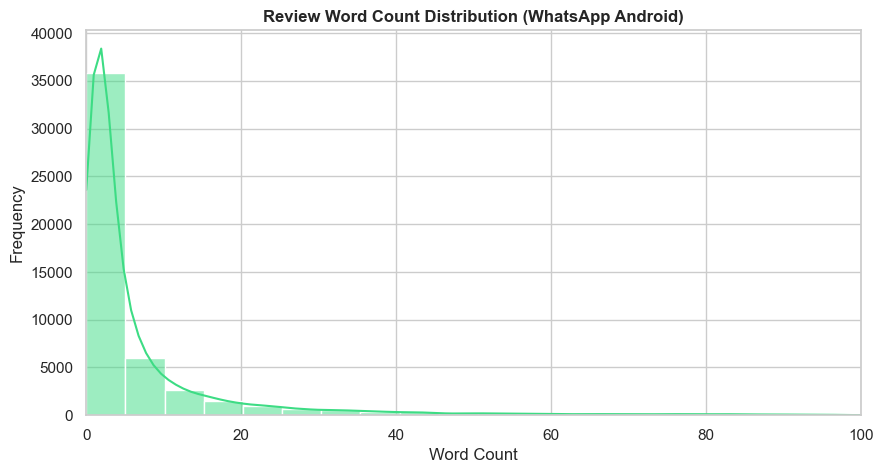

In [20]:
if 'content' in df.columns:
    # Calculate word count
    df['content'] = df['content'].fillna('').astype(str)
    df['word_count'] = df['content'].str.split().str.len()
    
    # Print statistical summary
    print("Word Count Summary Statistics:")
    print(df['word_count'].describe(percentiles=[.25, .5, .75, .90]).to_string())
    print("\n")
    
    # Plot the distribution
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x='word_count', binwidth=5, color="#3DDC84", kde=True)
    plt.title("Review Word Count Distribution (WhatsApp Android)", weight='bold')
    plt.xlabel("Word Count")
    plt.ylabel("Frequency")
    plt.xlim(0, 100) # Clip long outliers for readability
    plt.show()

### Interpretation: Word Count Density
**Observation:** As visualized in the distribution chart, the data is heavily right-skewed. The median review is only 2 words long, and 75% of all reviews are 6 words or fewer. Only the top 10% of reviews exceed 17 words.

**Engineering Conclusion:** This establishes a critical "noise floor" for the dataset. Since standard machine learning algorithms require sufficient semantic context to classify text accurately, any models leveraging this pipeline will likely need a filtering threshold (e.g., dropping reviews under 3 words) to ensure high-fidelity training data.

### 4. Geographic Fidelity (International Markers)
Because we passed `country='us'` into our scraper, we must verify that the API actually respected this parameter. We can test this by scanning the text for currency symbols and British English spelling variations that shouldn't appear in a strictly US dataset.

In [21]:
if 'content' in df.columns:
    text_data = df['content'].str.lower()
    pounds = text_data.str.contains('£').sum()
    euros = text_data.str.contains('€').sum()
    rupees = text_data.str.contains('₹').sum()
    
    # Regex to match exact words, preventing false positives
    uk_spelling = text_data.str.contains(r'\b(?:colour|favour|behaviour|programme|centre)\b', regex=True).sum()
    
    print(f"British Pounds (£):   {pounds}")
    print(f"Euros (€):            {euros}")
    print(f"Indian Rupees (₹):    {rupees}")
    print(f"UK Spelling Variants: {uk_spelling}")
    
    total_markers = pounds + euros + rupees + uk_spelling
    print("-" * 30)
    print(f"Total Markers Detected: {total_markers} out of {len(df)} rows")
    print(f"Geographic Leakage Rate: {(total_markers/len(df))*100:.4f}%")

British Pounds (£):   1
Euros (€):            1
Indian Rupees (₹):    1
UK Spelling Variants: 28
------------------------------
Total Markers Detected: 31 out of 50000 rows
Geographic Leakage Rate: 0.0620%


### Interpretation: Geographic Fidelity
**Observation:** Out of 50,000 reviews requested with the `country='us'` parameter, only 31 rows (0.062%) contained international currency symbols or British-English spelling variations. 

**Engineering Conclusion:** The Google Play API's geographic sorting is highly reliable, demonstrating a 99.93% accuracy rate for US localization. The negligible geographic leakage means no additional filtering logic needs to be written into the ETL pipeline to enforce country boundaries.

---
## Final Assessment & Decision: GO

Based on the profiling of this 50,000-record sample, the **Google Play Store API is approved** as a primary data source for the ETL pipeline. 

**Key Justifications:**
*   **Structural Integrity:** The API delivers highly structured data with 100% unique IDs and virtually zero missing values in the critical `content` field.
*   **Geographic Reliability:** The API successfully filters by region, ensuring compliance with US-only data requirements (99.93% accuracy).
*   **Volume vs. Noise:** While the dataset contains a high volume of short, repetitive text (41% duplication rate), this is an organic characteristic of app store user behavior, not a pipeline flaw. The sheer volume of incoming data ensures that even after aggressive downstream filtering for NLP tasks, there remains a massive corpus of high-signal text.

**Next Steps:** Proceed with deploying `android_pipeline.py` to automate continuous data extraction into the production database.